In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

RANDOM_STATE = 42

In [2]:
#Simple plot function to visualize a stock's price over time
def basic_stock_plot(stock_df, stock_ticker):
    plt.figure(figsize=(12,8))
    plt.plot(stock_df['Date'], stock_df['Close'], color = 'red', alpha=0.5)
    title_string = 'Visualization of ' + stock_ticker + ' Stock Price'
    plt.title(title_string)
    plt.xlabel('Date')
    plt.ylabel('Share Price')
    plt.show()

#Format and print a table to compare actual vs. predicted prices
def comp_table(actual_prices, predicted_high_prices, stock_ticker):
    comparison = pd.DataFrame({'Actual': actual_prices.flatten(), 'Predicted': predicted_high_prices.flatten()})
    table_title = stock_ticker + ' Prediction Comparison'
    print(table_title)
    print(comparison)

        Date        Open        High         Low       Close   Adj Close  \
0 2015-01-02  151.500000  151.600006  148.500000  149.169998  149.169998   
1 2015-01-05  148.809998  149.000000  146.779999  147.000000  147.000000   
2 2015-01-06  147.639999  148.529999  146.110001  146.839996  146.839996   
3 2015-01-07  147.940002  149.139999  147.649994  148.880005  148.880005   
4 2015-01-08  150.600006  151.369995  150.509995  151.369995  151.369995   

    Volume  
0  3436400  
1  4168800  
2  4116100  
3  4159100  
4  4282100  


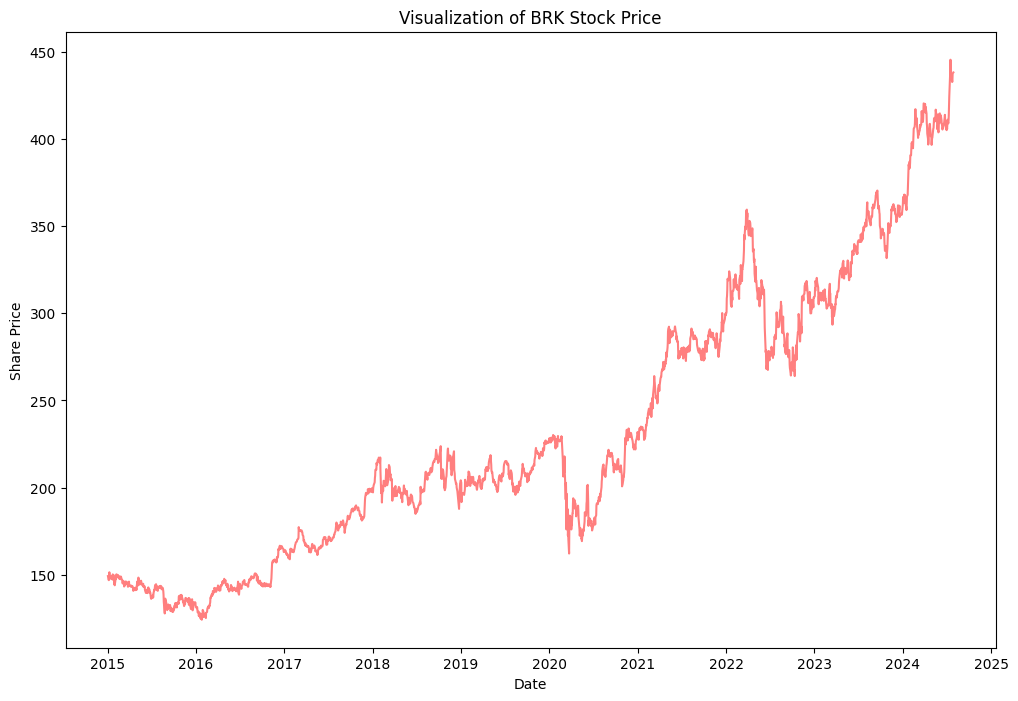

In [3]:
# Import and clean data
data = '../data/BRK.csv'
brk = pd.read_csv(data)
brk = brk.dropna()
brk['Date'] = pd.to_datetime(brk['Date'])

#Show first few rows of data
print(brk.head(5))

#Basic visualization
basic_stock_plot(brk, 'BRK')

In [4]:

# Define features, target. Shift features to match yesterday's features with today's target, since we want to predict tomorrow's price
brk_X = brk[['Open', 'High', 'Low', 'Adj Close', 'Volume']].head(-1)
brk_y = brk[['Close']].tail(-1).values
brk_dates = brk[['Date']].tail(-1)

# Split data for training, testing, splitting dates as well for later sorting/plotting
X_train_BRK, X_test_BRK, y_train_BRK, y_test_BRK, dates_train, dates_test = train_test_split(brk_X, brk_y, brk_dates, test_size=0.2, random_state=RANDOM_STATE)

In [5]:
# Construct and train model
forestModel_brk = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=RANDOM_STATE)
forestModel_brk.fit(X_train_BRK, y_train_BRK)

c:\Users\14236\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=10, n_estimators=500, random_state=42)

In [6]:
# Predict with model
brk_predicted = forestModel_brk.predict(X_test_BRK)

# Calculate and display performance metrics
rfMSE = mean_squared_error(y_test_BRK, brk_predicted)
rfR2 = r2_score(y_test_BRK, brk_predicted)

print(f"BRK Prediction MSE: {rfMSE:.4}")
print(f"BRK Prediction R2: {rfR2:.4}")

# Create a dataframe to store dates, actual values, and predicted values for sorting by date
results = pd.DataFrame({ 'Date': dates_test.values.flatten(), 'Actual': y_test_BRK.flatten(), 'Predicted': brk_predicted.flatten()})

# Resort randomized data
results = results.sort_values(by='Date')

comp_table(results['Actual'].values, results['Predicted'].values, 'BRK')

BRK Prediction MSE: 10.16
BRK Prediction R2: 0.9982
BRK Prediction Comparison
         Actual   Predicted
0    143.910004  145.709237
1    149.919998  148.860042
2    149.169998  148.072016
3    143.190002  145.660574
4    145.979996  144.841289
..          ...         ...
477  407.320007  406.943071
478  405.769989  407.807994
479  434.420013  418.016812
480  445.609985  436.880110
481  434.010010  436.361149

[482 rows x 2 columns]


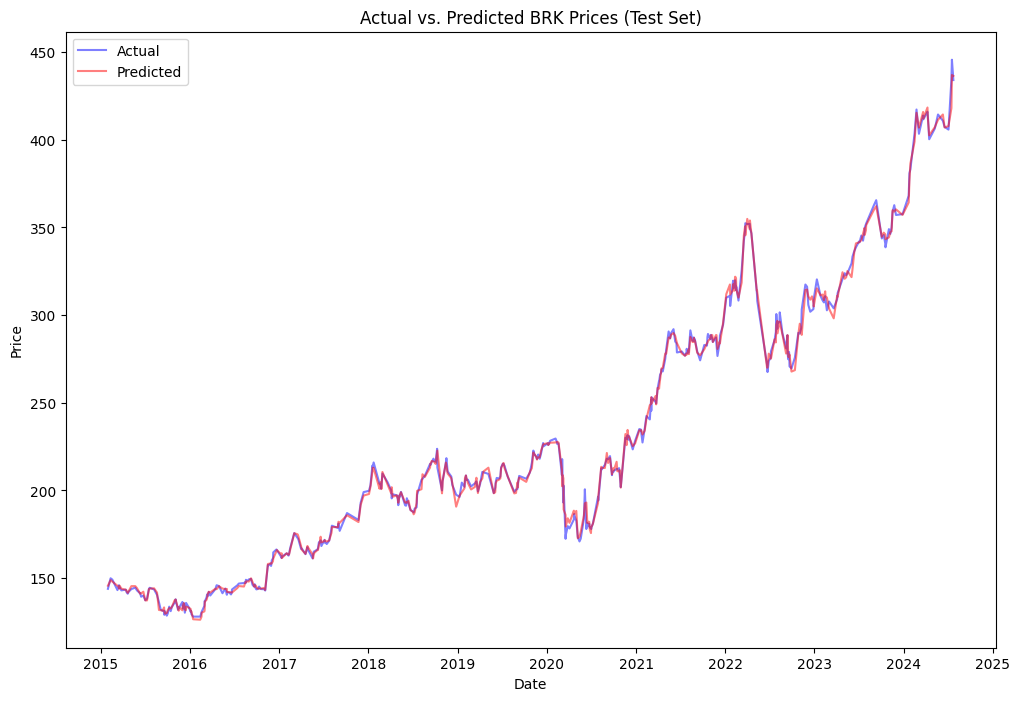

In [7]:
# Plot the actual vs predicted stock prices for test set
plt.figure(figsize=(12, 8))
plt.plot(results['Date'], results['Actual'], color='blue', alpha=0.5, label='Actual',)
plt.plot(results['Date'], results['Predicted'], color='red', alpha=0.5, label='Predicted')
plt.title('Actual vs. Predicted BRK Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100323  469033600
1 1980-12-15  0.122210  0.122210  0.121652  0.121652   0.095089  175884800
2 1980-12-16  0.113281  0.113281  0.112723  0.112723   0.088110  105728000
3 1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090291   86441600
4 1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092908   73449600


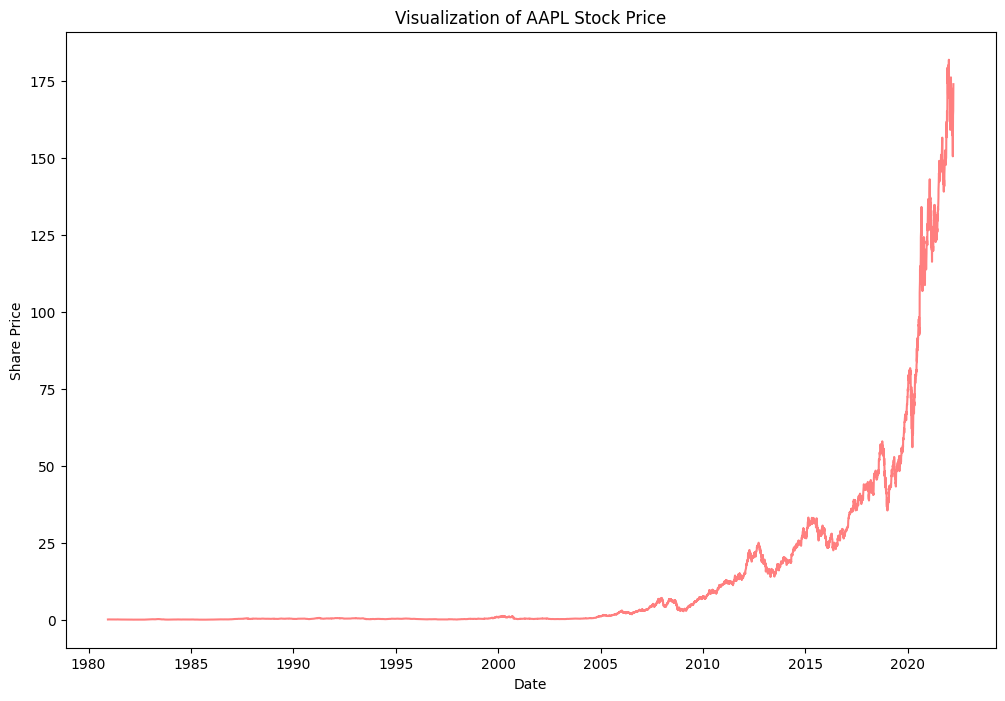

In [8]:
#Import and clean apple stock data
aapl = pd.read_csv('../data/AAPL.csv')

aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.dropna()

#Show first few rows of data
print(aapl.head(5))

#Basic visualization
basic_stock_plot(aapl, 'AAPL')

In [9]:
# Define features/targets for apple stock data
aapl_X = aapl[['Open', 'High', 'Low', 'Adj Close', 'Volume']].head(-1)
aapl_y = aapl[['Close']].tail(-1).values
aapl_dates = aapl[['Date']].tail(-1)

X_train_AAPL, X_test_AAPL, y_train_AAPL, y_test_AAPL, dates_train, dates_test = train_test_split(aapl_X, aapl_y, aapl_dates, test_size=0.2, random_state=RANDOM_STATE)

In [10]:
# Construct and train model
forestModel_aapl = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=RANDOM_STATE)
forestModel_aapl.fit(X_train_AAPL, y_train_AAPL)

c:\Users\14236\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=10, n_estimators=500, random_state=42)

In [11]:
# Predict with model
aapl_predicted = forestModel_aapl.predict(X_test_AAPL)

# Calculate and display performance metrics
rfMSE = mean_squared_error(y_test_AAPL, aapl_predicted)
rfR2 = r2_score(y_test_AAPL, aapl_predicted)

print(f"AAPL Prediction MSE: {rfMSE:.4}")
print(f"AAPL Prediction R2: {rfR2:.4}")

# Create a dataframe to store dates, actual values, and predicted values for sorting by date
results = pd.DataFrame({ 'Date': dates_test.values.flatten(), 'Actual': y_test_AAPL.flatten(), 'Predicted': aapl_predicted.flatten()})

# Resort randomized data
results = results.sort_values(by='Date')

comp_table(results['Actual'].values, results['Predicted'].values, 'AAPL')

AAPL Prediction MSE: 0.5871
AAPL Prediction R2: 0.9994
AAPL Prediction Comparison
          Actual   Predicted
0       0.121652    0.125723
1       0.118862    0.115312
2       0.158482    0.144244
3       0.156808    0.161337
4       0.143973    0.149574
...          ...         ...
2077  162.740005  161.599286
2078  158.520004  162.269072
2079  159.589996  154.688319
2080  160.619995  157.932836
2081  170.210007  169.144037

[2082 rows x 2 columns]


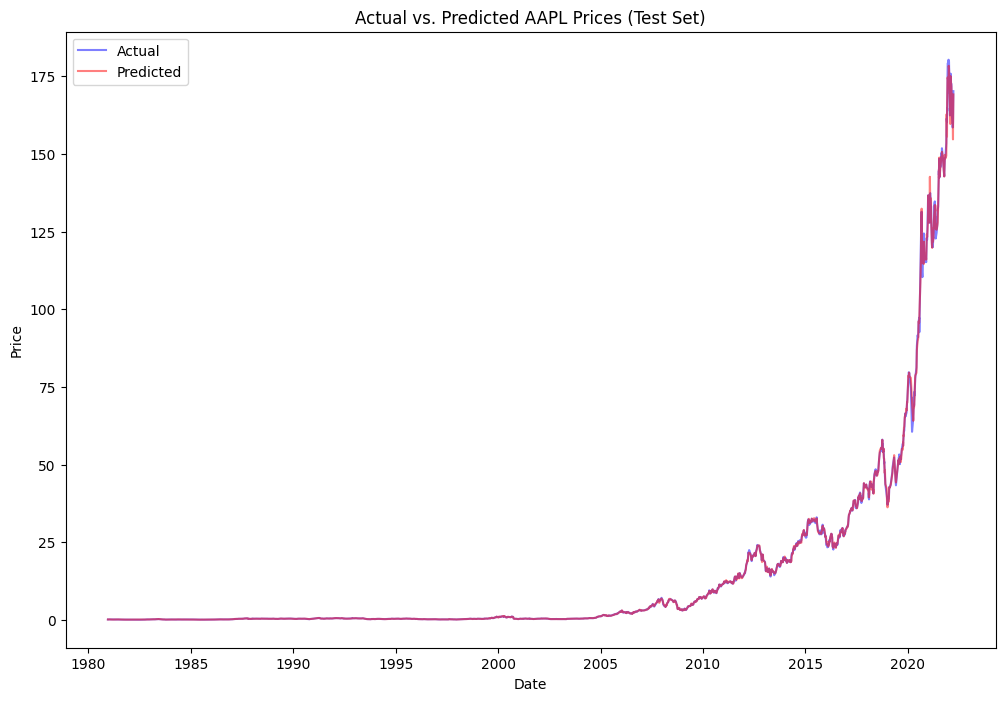

In [12]:
# Plot the actual vs predicted stock prices for test set
plt.figure(figsize=(12, 8))
plt.plot(results['Date'], results['Actual'], color='blue', alpha=0.5, label='Actual',)
plt.plot(results['Date'], results['Predicted'], color='red', alpha=0.5, label='Predicted')
plt.title('Actual vs. Predicted AAPL Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

        Date    Open    High      Low    Close   Volume
0 2010-09-09  102.50  102.50  101.140  101.320  26513.0
1 2010-09-10  101.68  101.86  101.296  101.780   8638.0
2 2010-09-13  102.96  103.14  102.500  103.060  33752.5
3 2010-09-14  102.84  103.48  102.380  103.038  59420.0
4 2010-09-15  102.62  103.38  102.400  103.300   9283.0


C:\Users\14236\AppData\Local\Temp\ipykernel_32952\2092271522.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  voo['Date'] = pd.to_datetime(voo['Date'])


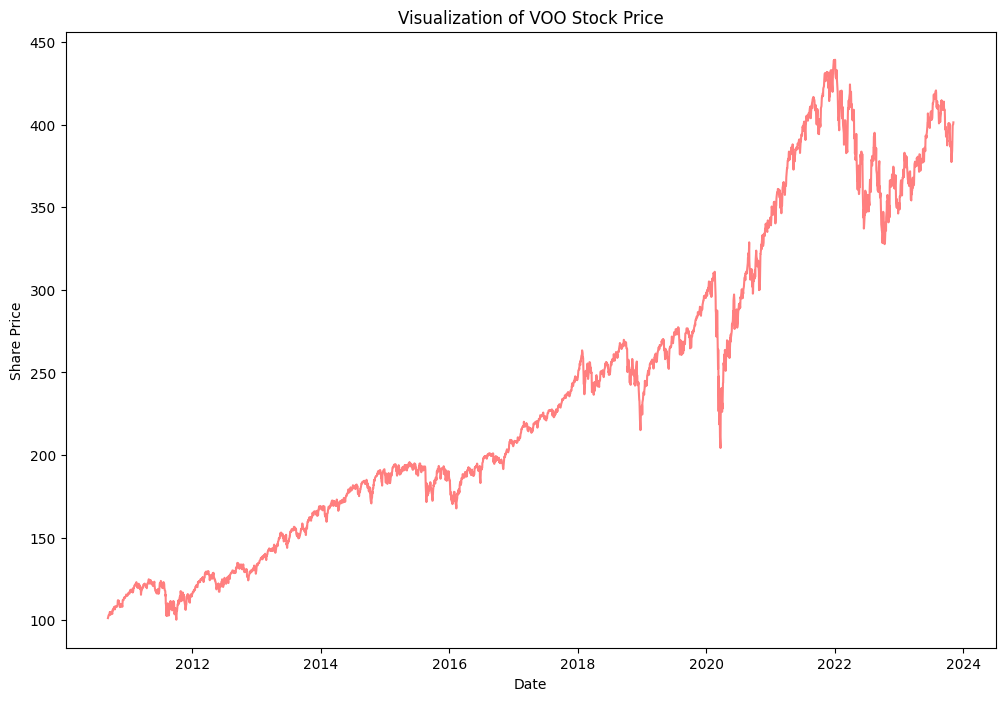

In [13]:
#Import and clean voo (Vanguard S&P 500 ETF) stock data
voo = pd.read_csv('../data/VOO.csv')

voo['Date'] = pd.to_datetime(voo['Date'])
voo = voo.dropna()

# Reverse voo order since it starts with recent dates as opposed to earlier dates
voo[:] = voo[::-1]

#Strip whitespace to maintain column names
voo.columns = voo.columns.str.strip()

#Show first few rows of data
print(voo.head(5))

basic_stock_plot(voo, 'VOO')

In [14]:
# Define features, target. Shift features to match yesterday's features with today's target, since we want to predict tomorrow's price
voo_X = voo[['Open', 'High', 'Low', 'Volume']].head(-1)
voo_y = voo[['Close']].tail(-1).values
voo_dates = voo[['Date']].tail(-1)

# Split data for training, testing, splitting dates as well for later sorting/plotting
X_train_VOO, X_test_VOO, y_train_VOO, y_test_VOO, dates_train, dates_test = train_test_split(voo_X, voo_y, voo_dates, test_size=0.2, random_state=RANDOM_STATE)

In [15]:
forestModel_voo = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=RANDOM_STATE)
forestModel_voo.fit(X_train_VOO, y_train_VOO)

c:\Users\14236\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=10, n_estimators=500, random_state=42)

In [16]:
# Predict with model
voo_predicted = forestModel_voo.predict(X_test_VOO)

# Calculate and display performance metrics
rfMSE = mean_squared_error(y_test_VOO, voo_predicted)
rfR2 = r2_score(y_test_VOO, voo_predicted)

print(f"VOO Prediction MSE: {rfMSE:.4}")
print(f"VOO Prediction R2: {rfR2:.4}")

# Create a dataframe to store dates, actual values, and predicted values for sorting by date
results = pd.DataFrame({ 'Date': dates_test.values.flatten(), 'Actual': y_test_VOO.flatten(), 'Predicted': voo_predicted.flatten()})

# Resort randomized data
results = results.sort_values(by='Date')

comp_table(results['Actual'].values, results['Predicted'].values, 'VOO')

VOO Prediction MSE: 9.891
VOO Prediction R2: 0.9989
VOO Prediction Comparison
      Actual   Predicted
0    101.780  103.344334
1    104.360  104.212975
2    106.116  104.142683
3    107.560  107.511682
4    108.340  107.599213
..       ...         ...
658  408.370  408.677085
659  398.520  399.773105
660  389.200  391.864270
661  381.860  375.972570
662  388.400  383.842905

[663 rows x 2 columns]


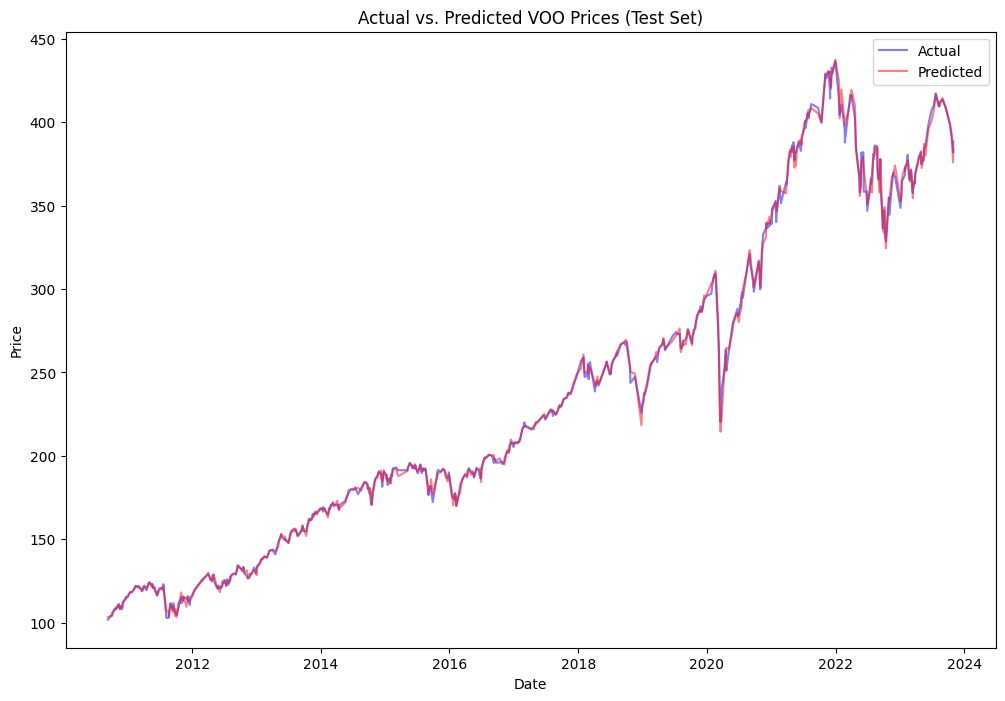

In [17]:
# Plot the actual vs predicted stock prices for test set
plt.figure(figsize=(12, 8))
plt.plot(results['Date'], results['Actual'], color='blue', alpha=0.5, label='Actual',)
plt.plot(results['Date'], results['Predicted'], color='red', alpha=0.5, label='Predicted')
plt.title('Actual vs. Predicted VOO Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()